In [1]:
import sys
import yaml
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
root = Path.cwd().parent.parent
sys.path.append(str(root))
plt.rcParams.update({"text.usetex": True, "font.family": "Computer Modern"}) 

from data.materials import hardening
from configs.materials import materials
from data.generators import InputsSignals
from data.materials import plot_responses
from utils.readable import dataset_str

figure_path = Path('/mnt/c/users/rdsup/desktop/1st-paper/figures')
das_path = Path('/mnt/c/users/rdsup/desktop/DAS2026')

with open(root / "configs" / "generators.yaml", "r") as f:
    config = yaml.safe_load(f)

with open(root  / "data" / "data_sets.yaml" , "r") as f:
    datasets = yaml.safe_load(f)

train_inp_names = datasets["train"]
eval_rand_inp_names = datasets["eval"]["rand"]
eval_crit_inp_names = datasets["eval"]["crit"]

train_inp_names.remove('combined_42_200')
eval_rand_inp_names.remove('combined_56_20')

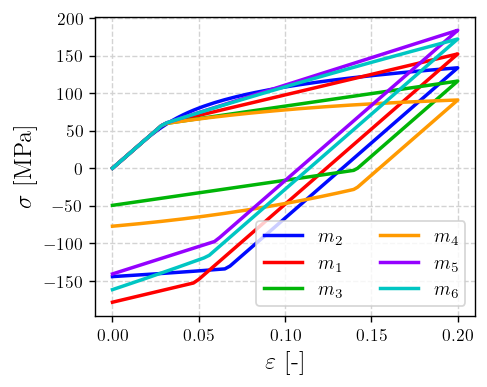

In [16]:
eps_max = 0.2

plt.figure(figsize=(5*0.8,4*0.8),dpi=125)
# plt.title('Constitutive models',fontsize=20)
eps = np.concatenate([
    np.linspace(0,eps_max,200),
    np.linspace(eps_max,-eps_max,200),
    np.linspace(-eps_max,0,200)
])

eps = 0.2* np.sin(np.linspace(0,np.pi,200))

for name, mat in materials.items():
    sig, _, _, _ = hardening(eps,mat['E'],mat['dalpha'],mat['Y'])
    plt.plot(eps,sig/1e6,color=materials[name]['color'],label=materials[name]['label'],lw=2)
plt.legend(loc='lower right',fontsize=11, ncol=2)
plt.xlabel(r'$\varepsilon$ [-]',fontsize=14)
plt.ylabel(r'$\sigma$ [MPa]',fontsize=14)
plt.grid(ls='--',c='lightgray')
plt.tight_layout()
plt.savefig(figure_path / 'reference-models.svg', format='svg')
plt.savefig(figure_path / 'reference-models.pdf', bbox_inches='tight')
plt.show()

In [2]:
folder_path = Path('..','..','data','input','train')
rand_inputs = [InputsSignals(folder_path / (inp_name + '.npy')) for inp_name in train_inp_names]
folder_path = Path('..','..','data','input','eval')
crit_inputs = [InputsSignals(folder_path / (inp_name + '.npy')) for inp_name in eval_crit_inp_names]

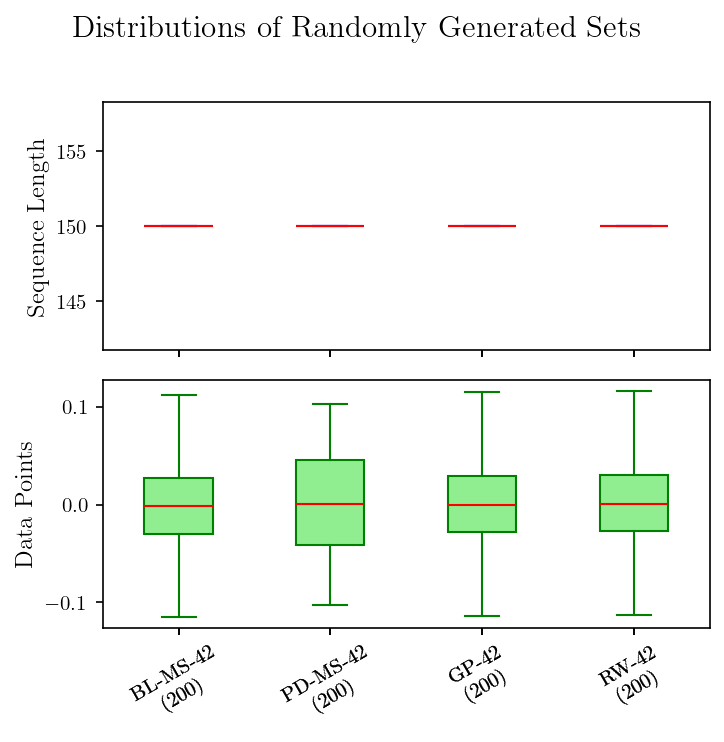

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(5, 5), dpi=150, sharex=True)
fig.suptitle('Distributions of Randomly Generated Sets', fontsize=15)

# Sequence lengths
ax[0].boxplot(
    [data.lengths for data in rand_inputs],
    tick_labels=[dataset_str(data.name) for data in rand_inputs],
    showfliers=False,   # hide outliers
    patch_artist=True,  # fill boxes with color
    boxprops=dict(facecolor='lightblue', color='blue'),
    medianprops=dict(color='red'),
    whiskerprops=dict(color='blue'),
    capprops=dict(color='blue')
)
ax[0].set_ylabel('Sequence Length', fontsize=12)

# Data points
ax[1].boxplot(
    [np.concatenate(data_set.u_list) for data_set in rand_inputs],
    tick_labels=[dataset_str(data_set.name) for data_set in rand_inputs],
    showfliers=False,   # hide outliers
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen', color='green'),
    medianprops=dict(color='red'),
    whiskerprops=dict(color='green'),
    capprops=dict(color='green')
)
ax[1].set_ylabel('Data Points', fontsize=12)

plt.xticks(rotation=30)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


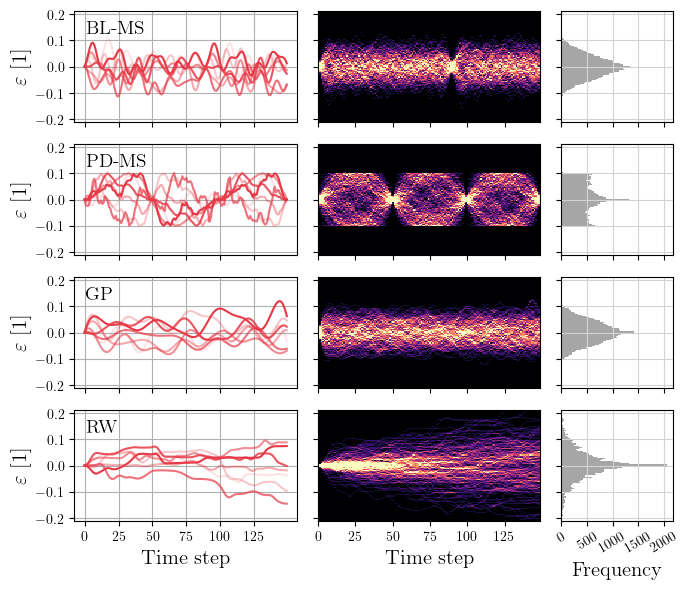

In [26]:
num = len(rand_inputs)
fig, ax = plt.subplots(
    num,3,figsize=(7,1.5*num), dpi=100, sharex='col', sharey='row',
    gridspec_kw={'width_ratios': [2, 2, 1]}
)

for i in range(num):
    rand_inputs[i].plot_samples(ax=ax[i,0],num_samples=7)
    rand_inputs[i].plot_histogram(ax=ax[i,1],bins_time=150,bins_value=100,vmin=0,vmax=10, cmap='magma', y_range=[-0.21,0.21])
    
    # Extract data: shape assumed to be (n_samples, time_steps)
    data = rand_inputs[i].u_list.flatten()
    ax[i, 2].hist(data, bins=100, orientation='horizontal', 
                  range=[-0.21, 0.21], color='gray', alpha=0.7)


    label_text = dataset_str(rand_inputs[i].name, seed=False, num=False)
    ax[i,0].text(0.05, 0.925, label_text, transform=ax[i,0].transAxes, 
                 fontsize=14, verticalalignment='top', fontweight='bold')
    
    ax[i,0].set_ylabel(r'$\varepsilon$ [1]',fontsize=15)
    
    
    ax[i,0].set_yticks([-0.2, -0.1,0,0.1,0.2])
    ax[i,0].set_xticks([i for i in range(0,150,25)])
    ax[i,1].set_yticks([-0.2, -0.1,0,0.1,0.2])
    ax[i,1].set_xticks([i for i in range(0,150,25)])

    ax[i,2].set_yticks([-0.2, -0.1,0,0.1,0.2])
    ax[i,2].set_xticks([i for i in range(0,2001,500)])
    ax[i,2].grid(ls='-',c='lightgray')
    ax[i,2].tick_params(axis='x', rotation=30)

ax[-1,0].set_xlabel('Time step',fontsize=15)
ax[-1,1].set_xlabel('Time step',fontsize=15)
ax[-1,2].set_xlabel('Frequency',fontsize=15)
plt.tight_layout()
plt.savefig(figure_path / 'random-input-sets.svg', format='svg')
plt.savefig(figure_path / 'random-input-sets.pdf', bbox_inches='tight')
plt.show()

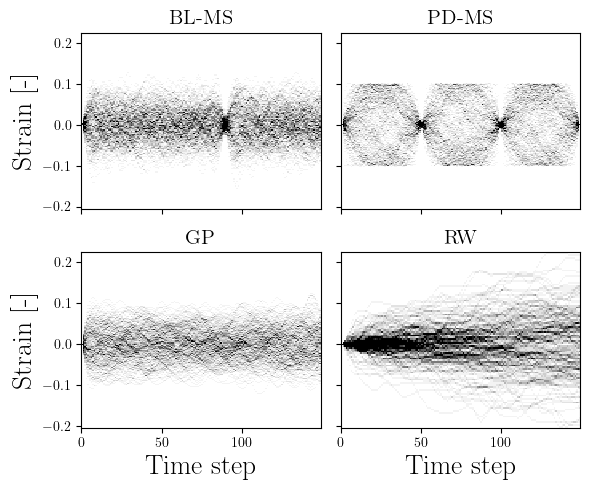

In [5]:
fig, ax = plt.subplots(2,2,figsize=(6,5), dpi=100,sharex=True,sharey=True)

# rand_inputs[i].plot_samples(ax=ax[0,0],num_samples=7)
rand_inputs[0].plot_histogram(ax=ax[0,0],bins_time=150,bins_value=100,vmin=0,vmax=10,cmap='Greys')
ax[0,0].set_title(f'{dataset_str(rand_inputs[0].name, seed=False, num=False)}',fontsize=15)
rand_inputs[1].plot_histogram(ax=ax[0,1],bins_time=150,bins_value=100,vmin=0,vmax=10,cmap='Greys')
ax[0,1].set_title(f'{dataset_str(rand_inputs[1].name, seed=False, num=False)}',fontsize=15)
rand_inputs[2].plot_histogram(ax=ax[1,0],bins_time=150,bins_value=100,vmin=0,vmax=10,cmap='Greys')
ax[1,0].set_title(f'{dataset_str(rand_inputs[2].name, seed=False, num=False)}',fontsize=15)
rand_inputs[3].plot_histogram(ax=ax[1,1],bins_time=150,bins_value=100,vmin=0,vmax=10,cmap='Greys')
ax[1,1].set_title(f'{dataset_str(rand_inputs[3].name, seed=False, num=False)}',fontsize=15)

# ax[0,0].set_ylabel(f'{dataset_str(rand_inputs[i].name, seed=False, num=False)}',fontsize=15)
ax[-1,0].set_xlabel('Time step',fontsize=20)
ax[-1,1].set_xlabel('Time step',fontsize=20)
ax[0,0].set_ylabel(r'Strain [-]',fontsize=20)
ax[1,0].set_ylabel(r'Strain [-]',fontsize=20)
plt.tight_layout()
plt.savefig(das_path / 'data-gen-meth-hist.svg', format='svg', bbox_inches='tight')
plt.show()

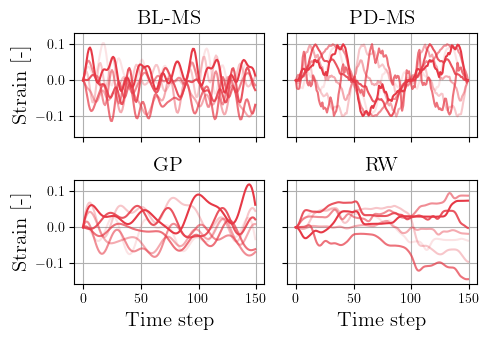

In [38]:
fig, ax = plt.subplots(2,2,figsize=(5,3.5), dpi=100,sharex=True,sharey=True)

# rand_inputs[i].plot_samples(ax=ax[0,0],num_samples=7)
rand_inputs[0].plot_samples(ax=ax[0,0],num_samples=7)
ax[0,0].set_title(f'{dataset_str(rand_inputs[0].name, seed=False, num=False)}',fontsize=15)
rand_inputs[1].plot_samples(ax=ax[0,1],num_samples=7)
ax[0,1].set_title(f'{dataset_str(rand_inputs[1].name, seed=False, num=False)}',fontsize=15)
rand_inputs[2].plot_samples(ax=ax[1,0],num_samples=7)
ax[1,0].set_title(f'{dataset_str(rand_inputs[2].name, seed=False, num=False)}',fontsize=15)
rand_inputs[3].plot_samples(ax=ax[1,1],num_samples=7)
ax[1,1].set_title(f'{dataset_str(rand_inputs[3].name, seed=False, num=False)}',fontsize=15)

# ax[0,0].set_ylabel(f'{dataset_str(rand_inputs[i].name, seed=False, num=False)}',fontsize=15)
ax[-1,0].set_xlabel('Time step',fontsize=15)
ax[-1,1].set_xlabel('Time step',fontsize=15)
ax[0,0].set_ylabel(r'Strain [-]',fontsize=15)
ax[1,0].set_ylabel(r'Strain [-]',fontsize=15)
plt.tight_layout()
plt.savefig(root / 'figures' / 'data-gen-meth-samples.png',dpi=250)
plt.show()

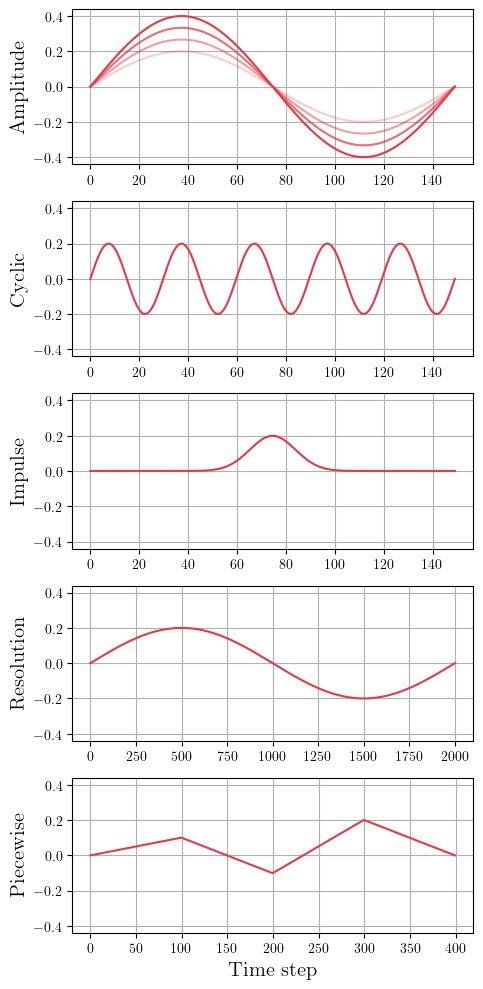

In [5]:
num = len(crit_inputs)
fig, ax = plt.subplots(num,figsize=(5,2*num), dpi=100,sharex=False,sharey=True)

for i in range(num):
    crit_inputs[i].plot_samples(ax=ax[i],num_samples=10)
    ax[i].set_ylabel(f'{crit_inputs[i].name.capitalize()}',fontsize=15)
ax[-1].set_xlabel('Time step',fontsize=15)
plt.tight_layout()
plt.savefig(figure_path / 'static-input-sets.svg', format='svg')
plt.savefig(figure_path / 'static-input-sets.pdf', bbox_inches='tight')
plt.show()

# Check saved responeses

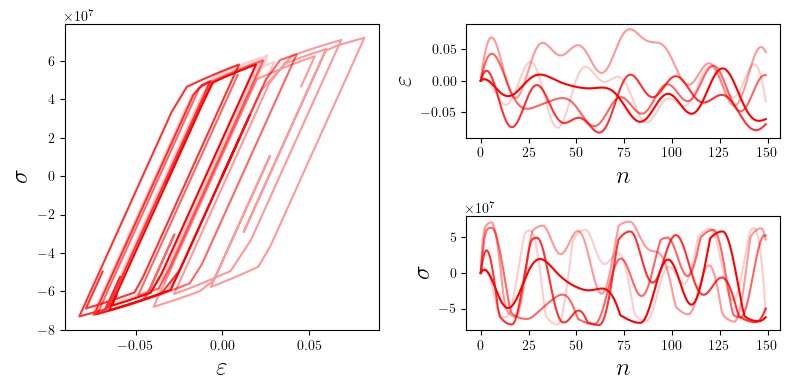

<Figure size 640x480 with 0 Axes>

In [8]:
mat_name = 'kinematic-armstrong-fredrick'
inp_type = 'random'
inp_name = 'gp_42_200'

eps_list, sig_list = load_responses(mat_name, inp_type, inp_name, data_dir='../data')
plot_responses(eps_list[:5], sig_list[:5],dpi=100)
plt.tight_layout()
plt.show()

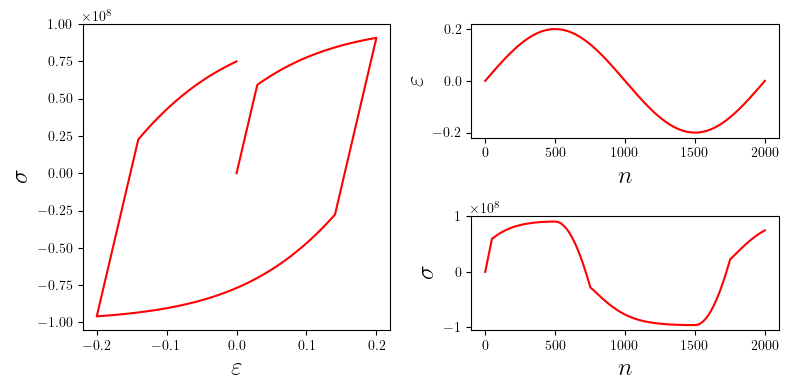

<Figure size 640x480 with 0 Axes>

In [9]:
mat_name = 'kinematic-armstrong-fredrick'
inp_type = 'static'
inp_name = 'resolution'

eps_list, sig_list = load_responses(mat_name, inp_type, inp_name, data_dir='../data')
plot_responses(eps_list[:5], sig_list[:5],dpi=100)
plt.tight_layout()
plt.show()

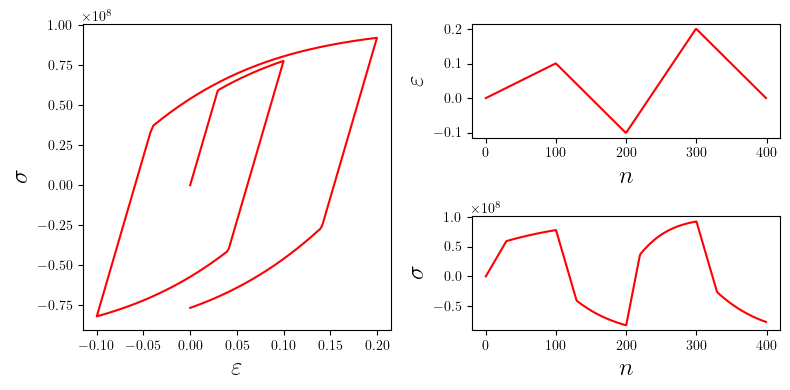

<Figure size 640x480 with 0 Axes>

In [10]:
mat_name = 'kinematic-armstrong-fredrick'
inp_type = 'static'
inp_name = 'piecewise'

eps_list, sig_list = load_responses(mat_name, inp_type, inp_name, data_dir='../data')
plot_responses(eps_list[:5], sig_list[:5],dpi=100)
plt.tight_layout()
plt.show()

In [11]:
mat_name = 'kinematic-armstrong-fredrick'
inp_type = 'static'
inp_name = 'impulse'

eps_list, sig_list = np.empty((0,150,1)), np.empty((0,150,1))
c_list = []
for mat_name in materials.keys():
    eps, sig = load_responses(mat_name, inp_type, inp_name, data_dir='../data')
    eps_list = np.concatenate([eps_list,eps])
    sig_list = np.concatenate([sig_list,sig])
    c_list.append(materials[mat_name]['color'])

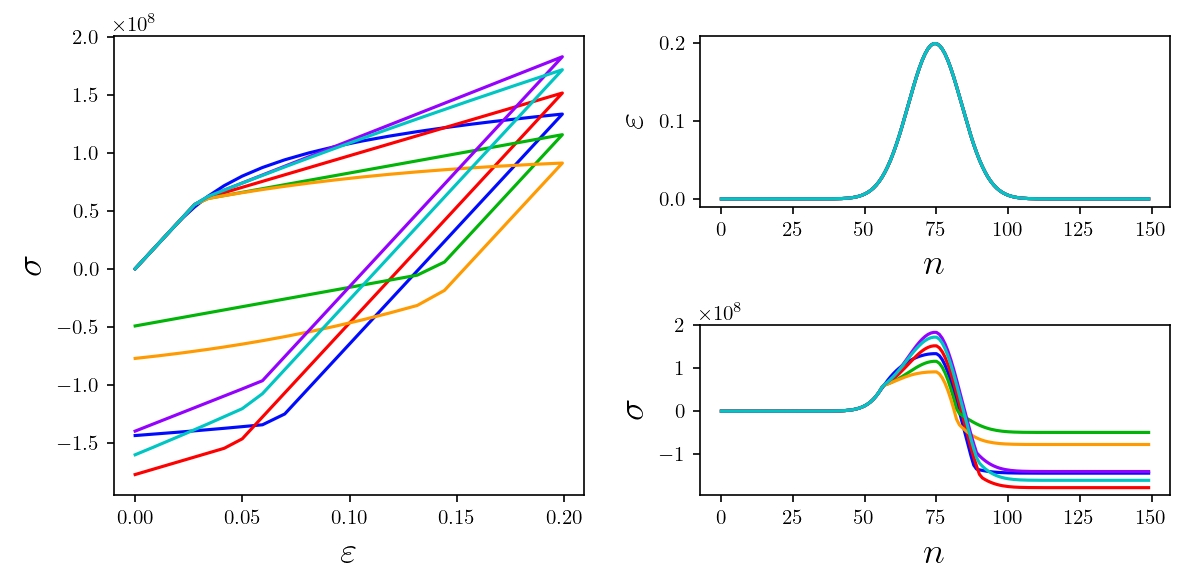

<Figure size 640x480 with 0 Axes>

In [13]:
fig, ax = plot_responses(eps_list, sig_list,c_list=c_list,alpha_list=[1]*len(c_list),dpi=150)
plt.tight_layout()
plt.show()

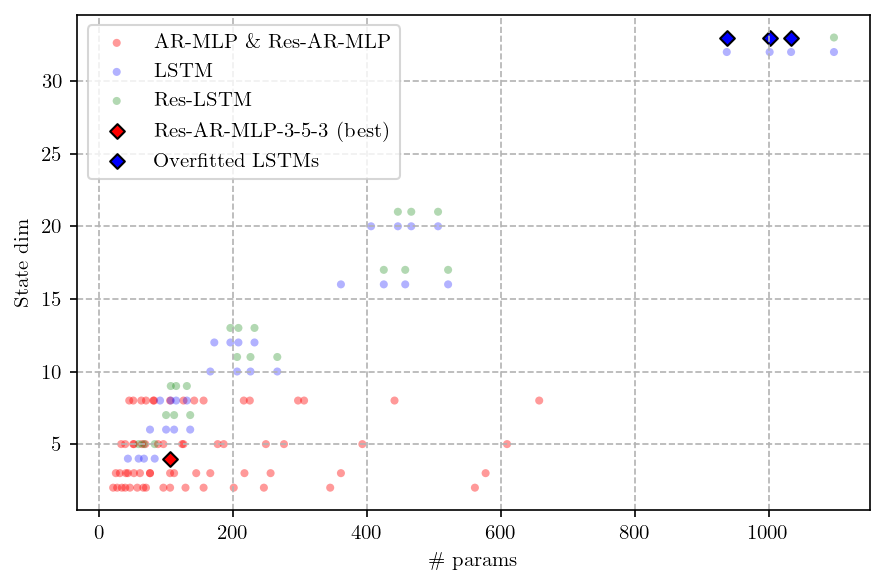

In [14]:
from itertools import product


def AR_MLP(k,p,q):
    num_params = (2*k + 1)*p + p + (q - 1)*(p**2 + p) + p + 1
    num_states = k
    return num_params, num_states

def LSTM(k,p,q):
    num_params = 4 * (p * (k + 1) + p**2 + 2*p) + (q - 1) * 4 * (2*p**2 + 2*p)
    num_params += p + 1
    num_states = 2*p*q
    return num_params, num_states


def get_list(kpq,func):
    ret = ([],[])
    for k,p,q in kpq:
        num_params, num_states = func(k,p,q)
        ret[0].append(num_params)
        ret[1].append(num_states)
    return ret

plt.figure(figsize=(6,4),dpi=150)

kpq = list(product([2,3,5,8],[2,3,5,8],[2,3,5,8]))
num_params, num_states = get_list(kpq,AR_MLP)
plt.scatter(num_params, num_states,c='red',label='AR-MLP \\& Res-AR-MLP',s=15,alpha=0.4,marker='o',edgecolors='none')


kpq = list(product([0,2,3,5],[2,3,5,8],[1,2]))
num_params, num_states = get_list(kpq,LSTM)
plt.scatter(num_params, num_states,c='blue',label='LSTM',s=15,alpha=0.3,marker='o',edgecolors='none')


kpq = list(product([2,3,5],[2,3,5,8],[1,2]))
num_params, num_states = get_list(kpq,LSTM)
plt.scatter(num_params, np.array(num_states)+1,c='green',label='Res-LSTM',s=15,alpha=0.3,marker='o',edgecolors='none')

kpq = [(3,5,3)]
num_params, num_states = get_list(kpq,AR_MLP)
plt.scatter(num_params, np.array(num_states)+1,c='red',edgecolors='black',s=25,marker='D',label='Res-AR-MLP-3-5-3 (best)')

kpq = [(2,8,2),(3,8,2),(0,8,2)]
num_params, num_states = get_list(kpq,LSTM)
plt.scatter(num_params, np.array(num_states)+1,c='blue',s=25,marker='D',edgecolors='black',label='Overfitted LSTMs')


plt.xlabel('\\# params')
plt.ylabel('State dim')
plt.legend()
plt.tight_layout()
plt.grid(True, which="both", ls="--", c='0.7')
plt.savefig(root / 'figures' / 'grid-search-params-NEW.png',dpi=250)
plt.show()